# Permutation Feature Importance for N-BEATS

Run your `N_BEATS.ipynb` notebook first up to the trained model and test set creation. This notebook expects these variables to already exist: `model`, `test_loader`, `y_scaler`, and `feature_cols`.


(1924653, 21)
(1924649, 9)
(186889, 9)
(186889, 9)
(186884, 10)
(186884, 10)
(186884, 10)
                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   
target_co2_15min       2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2 

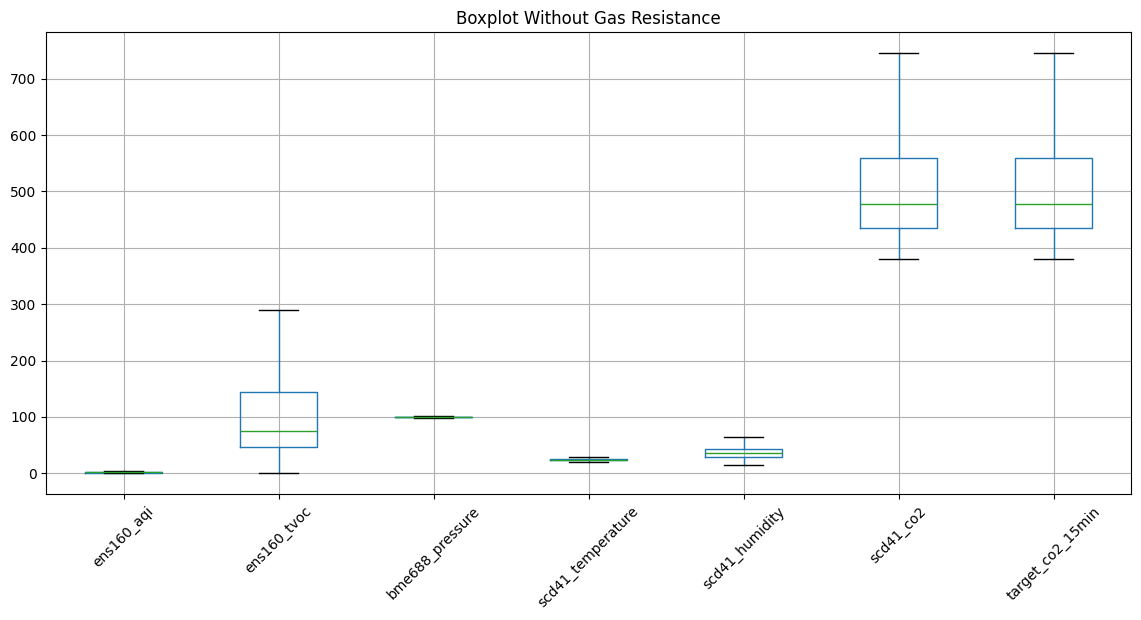

Train shape: (130816, 10)
Val shape: (28031, 10)
Test shape: (28037, 10)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381
Scaled X min/max: 0.0 1.0000000000000002
Scaled y min/max: 0.0 1.0000000000000002
X_train: (130516, 60, 8) y_train: (130516,)
X_val: (27731, 60, 8) y_val: (27731,)
X_test: (27737, 60, 8) y_test: (27737,)
Train batches: 2040
Val batches: 434
Test batches: 434
NBeats(
  (blocks): ModuleList(
    (0-1): 2 x NBeatsBlock(
      (fc): Sequential(
        (0): Linear(in_features=480, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5

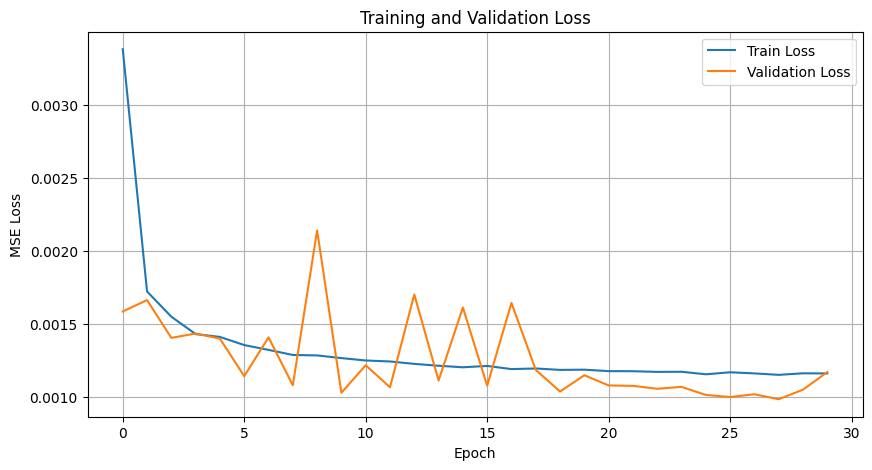

Metrics WITHOUT inverse scaling
MAE: 0.008642122149467468
MSE: 0.0004431040142662823
RMSE: 0.021050035968289516
R2: 0.9950741529464722
Predictions shape: (27737, 1)
Actuals shape: (27737, 1)
Metrics WITH inverse scaling
Test MAE: 3.1572988033294678
Test MSE: 59.14197540283203
Test RMSE: 7.6903820063006
Test R2: 0.9950741529464722


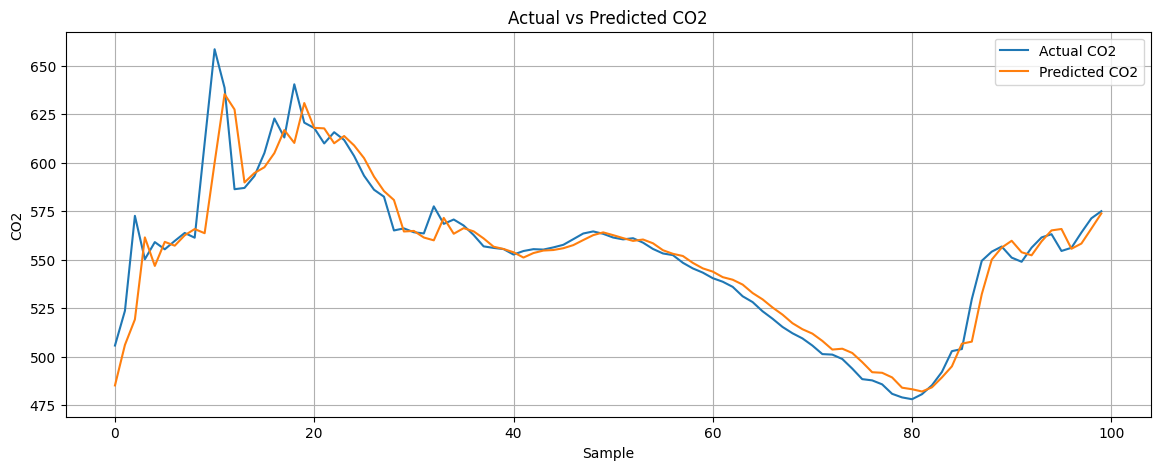

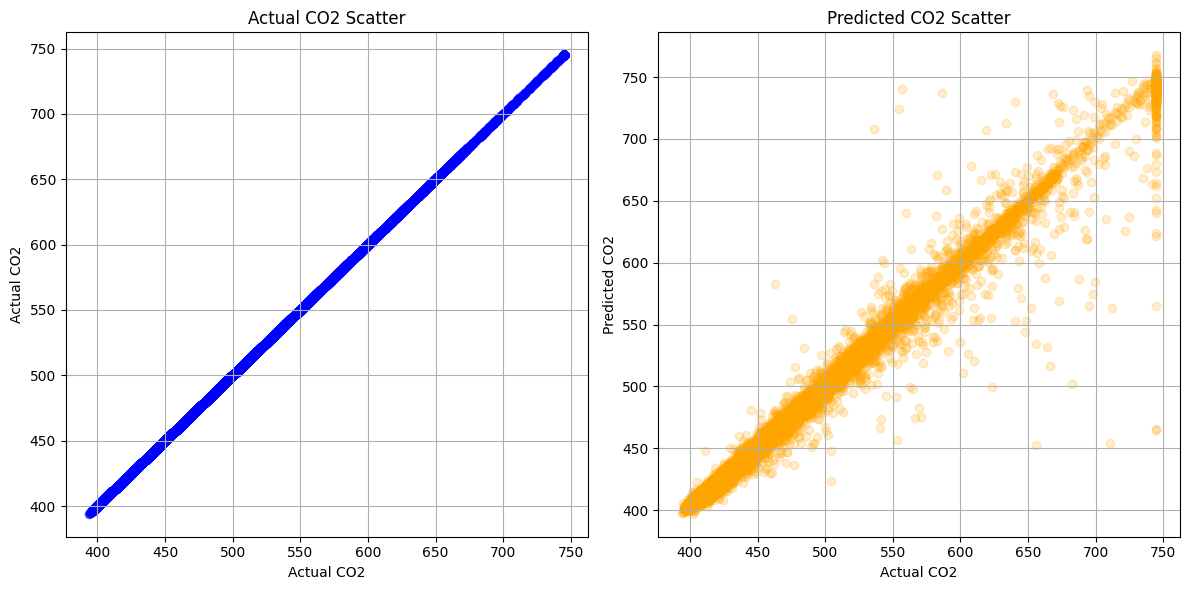

In [1]:
# Run the original N-BEATS notebook first.
# This keeps N_BEATS.ipynb unchanged and reuses its trained model and variables.
%run ./N_BEATS.ipynb

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Check Required Variables


In [3]:
required_variables = ["model", "test_loader", "y_scaler", "feature_cols"]
missing_variables = [name for name in required_variables if name not in globals()]

if missing_variables:
    raise NameError(
        "Please run N_BEATS.ipynb first. Missing variables: "
        + ", ".join(missing_variables)
    )

print("All required variables are available.")
print("Number of features:", len(feature_cols))
print("Features:", feature_cols)


All required variables are available.
Number of features: 8
Features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2']


## 2. Evaluation Function

This evaluates the trained model and converts predictions back to original CO2 scale using `y_scaler`.


In [4]:
def evaluate_model_original_scale(model, data_loader, y_scaler, max_batches=None):
    model.eval()

    predictions = []
    actuals = []

    device = next(model.parameters()).device

    with torch.no_grad():
        for batch_idx, (X_batch, y_batch) in enumerate(data_loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)

            predictions.append(y_pred.detach().cpu().numpy())
            actuals.append(y_batch.detach().cpu().numpy())

    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)

    predictions_original = y_scaler.inverse_transform(predictions)
    actuals_original = y_scaler.inverse_transform(actuals)

    mae = mean_absolute_error(actuals_original, predictions_original)
    mse = mean_squared_error(actuals_original, predictions_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals_original, predictions_original)

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "predictions": predictions_original,
        "actuals": actuals_original,
    }


## 3. Baseline Test Performance


In [5]:
baseline_results = evaluate_model_original_scale(
    model=model,
    data_loader=test_loader,
    y_scaler=y_scaler,
)

print("Baseline Test Metrics")
print("MAE:", baseline_results["mae"])
print("MSE:", baseline_results["mse"])
print("RMSE:", baseline_results["rmse"])
print("R2:", baseline_results["r2"])


Baseline Test Metrics
MAE: 3.1572988033294678
MSE: 59.14197540283203
RMSE: 7.6903820063006
R2: 0.9950741529464722


## 4. Permutation Feature Importance Function

For each feature, this shuffles that feature across test samples while keeping the full 60-step time window together. If model error increases strongly after shuffling a feature, that feature is important.


In [6]:
def permutation_feature_importance_nbeats(
    model,
    data_loader,
    feature_cols,
    y_scaler,
    n_repeats=10,
    metric="rmse",
    random_state=42,
    max_batches=None,
    exclude_features=None,
):
    """
    Permutation Feature Importance for N-BEATS time-series model.

    Important:
    - Input shape is expected as: [batch_size, time_steps, num_features]
    - For each feature, the full time window is permuted across samples.
    - This preserves the 60-step temporal pattern inside each window.
    - Feature indexes remain correct even when excluding features like station_id.
    """

    if exclude_features is None:
        exclude_features = []

    rng = np.random.default_rng(random_state)
    device = next(model.parameters()).device

    baseline = evaluate_model_original_scale(
        model=model,
        data_loader=data_loader,
        y_scaler=y_scaler,
        max_batches=max_batches,
    )

    baseline_score = baseline[metric]
    importance_rows = []

    print(f"Baseline {metric.upper()}: {baseline_score:.4f}")
    print("Starting permutation feature importance...")

    for feature_idx, feature_name in enumerate(feature_cols):

        # This avoids the index-shifting problem
        if feature_name in exclude_features:
            print(f"Skipping feature: {feature_name}")
            continue

        repeated_scores = []

        for repeat in range(n_repeats):
            model.eval()
            permuted_predictions = []
            permuted_actuals = []

            with torch.no_grad():
                for batch_idx, (X_batch, y_batch) in enumerate(data_loader):
                    if max_batches is not None and batch_idx >= max_batches:
                        break

                    X_batch = X_batch.to(device)
                    y_batch = y_batch.to(device)

                    X_permuted = X_batch.clone()

                    # Shuffle full feature windows across samples in the batch
                    permutation_idx = torch.tensor(
                        rng.permutation(X_permuted.shape[0]),
                        device=device,
                    )

                    X_permuted[:, :, feature_idx] = X_permuted[
                        permutation_idx,
                        :,
                        feature_idx,
                    ]

                    y_pred = model(X_permuted)

                    permuted_predictions.append(
                        y_pred.detach().cpu().numpy()
                    )
                    permuted_actuals.append(
                        y_batch.detach().cpu().numpy()
                    )

            permuted_predictions = np.vstack(permuted_predictions)
            permuted_actuals = np.vstack(permuted_actuals)

            # Convert scaled values back to original CO2 scale
            permuted_predictions_original = y_scaler.inverse_transform(
                permuted_predictions
            )

            permuted_actuals_original = y_scaler.inverse_transform(
                permuted_actuals
            )

            if metric == "rmse":
                score = np.sqrt(
                    mean_squared_error(
                        permuted_actuals_original,
                        permuted_predictions_original,
                    )
                )

            elif metric == "mae":
                score = mean_absolute_error(
                    permuted_actuals_original,
                    permuted_predictions_original,
                )

            elif metric == "mse":
                score = mean_squared_error(
                    permuted_actuals_original,
                    permuted_predictions_original,
                )

            elif metric == "r2":
                score = r2_score(
                    permuted_actuals_original,
                    permuted_predictions_original,
                )

            else:
                raise ValueError(
                    "metric must be one of: rmse, mae, mse, r2"
                )

            repeated_scores.append(score)

        mean_score = np.mean(repeated_scores)
        std_score = np.std(repeated_scores)

        # For error metrics, higher score after permutation means more important.
        # For R2, lower score after permutation means more important.
        if metric == "r2":
            importance = baseline_score - mean_score
        else:
            importance = mean_score - baseline_score

        importance_rows.append(
            {
                "feature": feature_name,
                f"baseline_{metric}": baseline_score,
                f"permuted_{metric}_mean": mean_score,
                f"permuted_{metric}_std": std_score,
                "importance": importance,
            }
        )

        print(
            f"{feature_name}: "
            f"permuted_{metric}_mean={mean_score:.4f}, "
            f"importance={importance:.4f}"
        )

    importance_df = pd.DataFrame(importance_rows)

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False,
    ).reset_index(drop=True)

    return importance_df

## 5. Run Permutation Feature Importance


In [7]:
pfi_df = permutation_feature_importance_nbeats(
    model=model,
    data_loader=test_loader,
    feature_cols=feature_cols,
    y_scaler=y_scaler,
    n_repeats=10,
    metric="rmse",
    random_state=42,
)

pfi_df

Baseline RMSE: 7.6904
Starting permutation feature importance...
station_id: permuted_rmse_mean=7.6916, importance=0.0012
ens160_aqi: permuted_rmse_mean=7.7484, importance=0.0581
ens160_tvoc: permuted_rmse_mean=7.9072, importance=0.2168
bme688_gas_resistance: permuted_rmse_mean=7.6849, importance=-0.0055
bme688_pressure: permuted_rmse_mean=7.6938, importance=0.0035
scd41_temperature: permuted_rmse_mean=7.7118, importance=0.0214
scd41_humidity: permuted_rmse_mean=7.6867, importance=-0.0037
scd41_co2: permuted_rmse_mean=42.5064, importance=34.8160


,feature,baseline_rmse,permuted_rmse_mean,permuted_rmse_std,importance
0,scd41_co2,7.690382,42.506416,0.313738,34.816034
1,ens160_tvoc,7.690382,7.907156,0.015256,0.216774
2,ens160_aqi,7.690382,7.748434,0.004534,0.058052
3,scd41_temperature,7.690382,7.711816,0.006004,0.021434
4,bme688_pressure,7.690382,7.693839,0.002130,0.003457
5,station_id,7.690382,7.691556,0.000615,0.001174
6,scd41_humidity,7.690382,7.686711,0.001941,-0.003671
7,bme688_gas_resistance,7.690382,7.684887,0.001467,-0.005495


## 6. Optional: Exclude `station_id`

Use this version if you want importance only for sensor values and not the station identifier.


In [8]:
pfi_without_station_df = permutation_feature_importance_nbeats(
    model=model,
    data_loader=test_loader,
    feature_cols=feature_cols,
    y_scaler=y_scaler,
    n_repeats=10,
    metric="rmse",
    random_state=42,
    exclude_features=["station_id"],
)

pfi_without_station_df

Baseline RMSE: 7.6904
Starting permutation feature importance...
Skipping feature: station_id
ens160_aqi: permuted_rmse_mean=7.7499, importance=0.0596
ens160_tvoc: permuted_rmse_mean=7.9180, importance=0.2276
bme688_gas_resistance: permuted_rmse_mean=7.6868, importance=-0.0036
bme688_pressure: permuted_rmse_mean=7.6939, importance=0.0035
scd41_temperature: permuted_rmse_mean=7.7184, importance=0.0280
scd41_humidity: permuted_rmse_mean=7.6870, importance=-0.0034
scd41_co2: permuted_rmse_mean=42.5427, importance=34.8524


,feature,baseline_rmse,permuted_rmse_mean,permuted_rmse_std,importance
0,scd41_co2,7.690382,42.542747,0.382055,34.852365
1,ens160_tvoc,7.690382,7.918012,0.022210,0.227630
2,ens160_aqi,7.690382,7.749946,0.008222,0.059564
3,scd41_temperature,7.690382,7.718426,0.008847,0.028044
4,bme688_pressure,7.690382,7.693859,0.001465,0.003477
5,scd41_humidity,7.690382,7.686981,0.001619,-0.003401
6,bme688_gas_resistance,7.690382,7.686821,0.003665,-0.003561


## 7. Plot Feature Importance


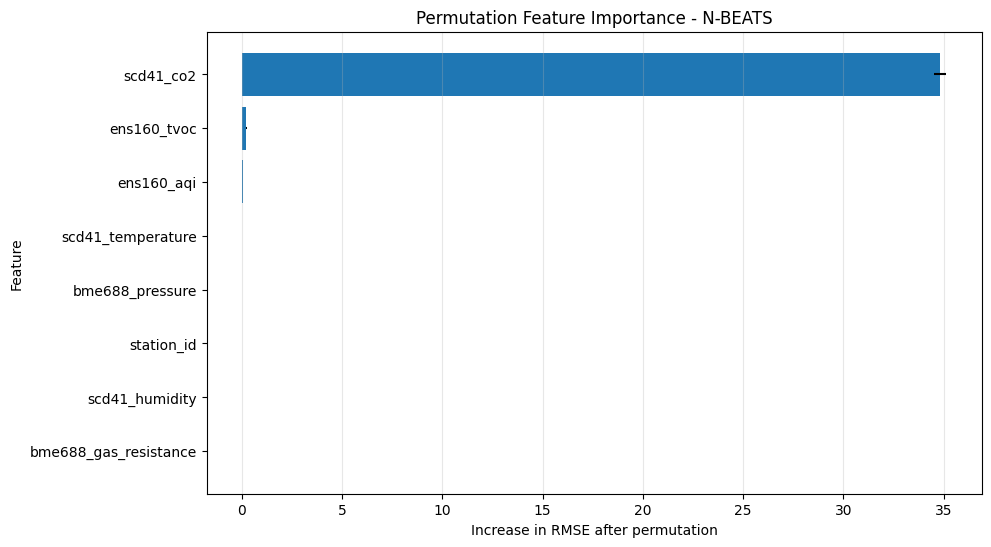

In [9]:
plot_df = pfi_df.copy()

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"],
    plot_df["importance"],
    xerr=plot_df["permuted_rmse_std"],
)

plt.xlabel("Increase in RMSE after permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - N-BEATS")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()


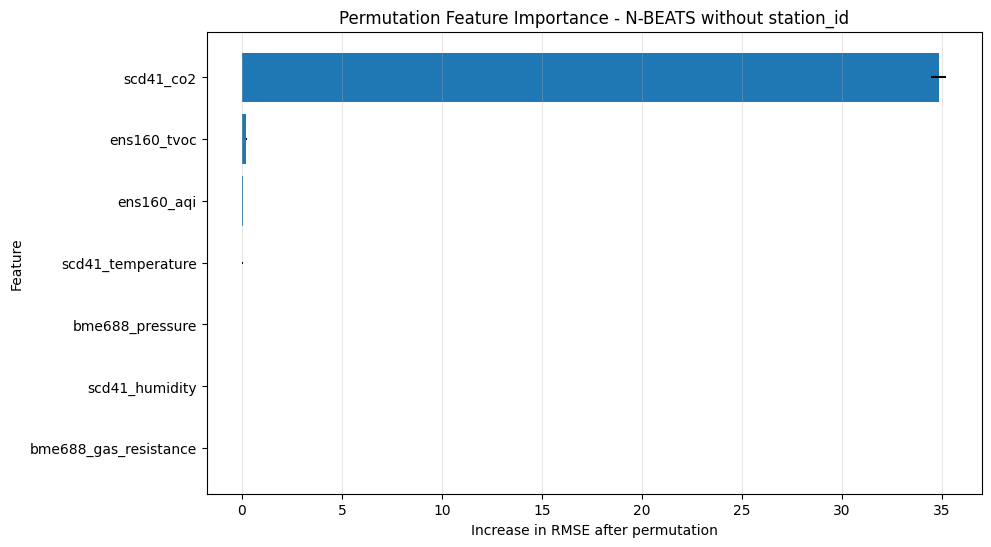

In [10]:
plot_df_without_station = pfi_without_station_df.copy()

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df_without_station["feature"],
    plot_df_without_station["importance"],
    xerr=plot_df_without_station["permuted_rmse_std"],
)

plt.xlabel("Increase in RMSE after permutation")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - N-BEATS without station_id")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

## 8. Save Results


In [12]:
output_path_all = "/Volumes/Hackintosh/Users/Manvi/TSA/output/N_BEATS_permutation_feature_importance_all_features.csv"
output_path_without_station = "/Volumes/Hackintosh/Users/Manvi/TSA/output/N_BEATS_permutation_feature_importance_without_station.csv"

pfi_df.to_csv(output_path_all, index=False)
pfi_without_station_df.to_csv(output_path_without_station, index=False)

print("Saved:", output_path_all)
print("Saved:", output_path_without_station)

Saved: /Volumes/Hackintosh/Users/Manvi/TSA/output/N_BEATS_permutation_feature_importance_all_features.csv
Saved: /Volumes/Hackintosh/Users/Manvi/TSA/output/N_BEATS_permutation_feature_importance_without_station.csv
